# Data Profiling y Calidad de Datos - SISMEPRE

## Objetivo
Este notebook documenta el profiling de SISMEPRE en la capa Bronze. El objetivo es describir la estructura de las tablas principales, entender la tabla central de respuestas y evaluar su calidad con ocho dimensiones explicadas de manera entendible.

## Herramientas
- Python con `pandas`, `numpy` y `matplotlib`
- Tablas CSV aterrizadas en `data/bronze/sismepre`
- Catalogos y diccionarios asociados a la fuente

## Alcance
Se revisan las tablas principales de SISMEPRE disponibles en Bronze. El data profiling se concentra en `rentas_respuestas.csv`, pero se complementa con preguntas, formularios y catalogos para revisar relaciones e integridad referencial.


In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display, Markdown
except ImportError:
    def display(obj):
        print(obj)

    def Markdown(text):
        return text

plt.style.use('default')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SISMEPRE_PATH = PROJECT_ROOT / 'data' / 'bronze' / 'sismepre'


## 1. Carga del dataset

Primero se verifica que archivos de SISMEPRE estan realmente disponibles en Bronze. Luego se cargan las tablas principales para analizarlas en conjunto, priorizando la tabla de respuestas porque es el centro del analisis posterior.


In [2]:
expected_files = [
    'rentas_preguntas.csv', 'rentas_estadistica.csv', 'rentas_formulario.csv',
    'rentas_esat_estadistica_atm.csv', 'rentas_respuestas.csv', 'rentas_ano_aplicacion.csv',
    'rentas_entidad_estado.csv', 'rentas_preguntas_diccionario.csv', 'rentas_estadistica_diccionario.csv',
    'rentas_formulario_diccionario.csv', 'rentas_respuestas_diccionario.csv',
    'rentas_entidad_estado_diccionario.csv', 'rentas_ano_aplicacion_diccionario.csv',
    'rentas_esat_estadistica_atm_diccionario.csv'
]

availability_df = pd.DataFrame({
    'filename': expected_files,
    'available_in_bronze': [(SISMEPRE_PATH / file_name).exists() for file_name in expected_files]
})

def read_csv_if_exists(file_name: str) -> pd.DataFrame:
    file_path = SISMEPRE_PATH / file_name
    if not file_path.exists():
        return pd.DataFrame()
    frame = pd.read_csv(file_path, encoding='utf-8-sig', low_memory=False)
    frame.columns = [column.replace('﻿', '').strip() for column in frame.columns]
    frame['source_file'] = file_name
    return frame

tables = {
    'preguntas': read_csv_if_exists('rentas_preguntas.csv'),
    'estadistica': read_csv_if_exists('rentas_estadistica.csv'),
    'formulario': read_csv_if_exists('rentas_formulario.csv'),
    'esat_estadistica_atm': read_csv_if_exists('rentas_esat_estadistica_atm.csv'),
    'respuestas': read_csv_if_exists('rentas_respuestas.csv'),
    'ano_aplicacion': read_csv_if_exists('rentas_ano_aplicacion.csv'),
    'entidad_estado': read_csv_if_exists('rentas_entidad_estado.csv'),
}

respuestas_df = tables['respuestas'].copy()
preguntas_df = tables['preguntas'].copy()
formulario_df = tables['formulario'].copy()
ano_aplicacion_df = tables['ano_aplicacion'].copy()

for column in ['RESPUESTA_ID', 'PREGUNTA_ID', 'FORMULARIO_ID', 'ANO_APLICACION', 'PERIODO', 'SEC_EJEC', 'RESPUESTA_ENTERO', 'RESPUESTA_DECIMAL']:
    if column in respuestas_df.columns:
        respuestas_df[column] = pd.to_numeric(respuestas_df[column], errors='coerce')

for frame in [preguntas_df, formulario_df, ano_aplicacion_df]:
    for column in ['PREGUNTA_ID', 'FORMULARIO_ID', 'ANO_APLICACION', 'PERIODO']:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors='coerce')

table_shapes = pd.DataFrame([
    {'table': table_name, 'rows': frame.shape[0], 'columns': frame.shape[1]}
    for table_name, frame in tables.items()
])

print(f'Archivos esperados: {len(expected_files)}')
print(f'Archivos disponibles: {int(availability_df["available_in_bronze"].sum())}')
display(availability_df)
display(table_shapes)


Archivos esperados: 14
Archivos disponibles: 13


,filename,available_in_bronze
0,rentas_preguntas.csv,True
1,rentas_estadistica.csv,True
2,rentas_formulario.csv,True
3,rentas_esat_estadistica_atm.csv,True
4,rentas_respuestas.csv,True
5,rentas_ano_aplicacion.csv,True
6,rentas_entidad_estado.csv,True
7,rentas_preguntas_diccionario.csv,True
8,rentas_estadistica_diccionario.csv,True
9,rentas_formulario_diccionario.csv,True


,table,rows,columns
0,preguntas,696,16
1,estadistica,233,8
2,formulario,94,11
3,esat_estadistica_atm,133172,43
4,respuestas,174210,12
5,ano_aplicacion,26,10
6,entidad_estado,19037,15


## 2. Entendimiento inicial de la estructura

Esta seccion ayuda a entender la forma de la fuente antes del profiling. En SISMEPRE no se trabaja con un solo archivo plano, sino con varias tablas relacionadas, por eso se muestra una vista general de la tabla central y de los catalogos mas importantes.


In [3]:
respuestas_summary = pd.DataFrame({
    'column': respuestas_df.columns,
    'dtype': respuestas_df.dtypes.astype(str).values,
    'non_null_count': respuestas_df.notna().sum().values,
    'missing_ratio': respuestas_df.isna().mean().round(4).values,
    'unique_values': [respuestas_df[column].nunique(dropna=True) for column in respuestas_df.columns],
}).sort_values(['missing_ratio', 'unique_values'], ascending=[False, False])

print(f'Tabla principal analizada: rentas_respuestas.csv con {len(respuestas_df):,} filas'.replace(',', '.'))
display(respuestas_df.head())
display(respuestas_summary)
display(respuestas_df.describe(include='all').T)

if not preguntas_df.empty:
    display(preguntas_df[['PREGUNTA_ID', 'FORMULARIO_ID', 'DESCRIPCION']].head())
if not formulario_df.empty:
    display(formulario_df[['FORMULARIO_ID', 'TITULO', 'TIPO_FORMULARIO']].head())


Tabla principal analizada: rentas_respuestas.csv con 174.210 filas


,RESPUESTA_FECHA,RESPUESTA_TEXTO,PERIODO,RESPUESTA_ID,RESPUESTA_DECIMAL,FORMULARIO_ID,ANO_APLICACION,PREGUNTA_ID,ESTADO_REGISTRO,SEC_EJEC,RESPUESTA_ENTERO,source_file
0,,5,1,1,0.0,1,2022,1,A,300348,0,rentas_respuestas.csv
1,,0,1,2,0.0,1,2022,9,A,300348,0,rentas_respuestas.csv
2,,UNIDAD DE ADMINISTRACION TRIBUTARIA,1,3,0.0,1,2022,10,A,300348,0,rentas_respuestas.csv
3,,0,1,4,0.0,1,2022,11,A,300348,2,rentas_respuestas.csv
4,,N,1,5,0.0,1,2022,12,A,300348,0,rentas_respuestas.csv


,column,dtype,non_null_count,missing_ratio,unique_values
4,RESPUESTA_DECIMAL,float64,174210,0.0,5310
10,RESPUESTA_ENTERO,int64,174210,0.0,4683
1,RESPUESTA_TEXTO,object,174210,0.0,4656
9,SEC_EJEC,int64,174210,0.0,885
0,RESPUESTA_FECHA,object,174210,0.0,723
3,RESPUESTA_ID,int64,174210,0.0,184
7,PREGUNTA_ID,int64,174210,0.0,142
5,FORMULARIO_ID,int64,174210,0.0,6
6,ANO_APLICACION,int64,174210,0.0,4
2,PERIODO,int64,174210,0.0,2


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RESPUESTA_FECHA,174210,723,,170108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RESPUESTA_TEXTO,174210,4656,0,89046,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PERIODO,174210.0,NaN,NaN,NaN,1.82435,0.380523,1.0,2.0,2.0,2.0,2.0
RESPUESTA_ID,174210.0,NaN,NaN,NaN,49.052959,29.23172,1.0,24.0,48.0,72.0,184.0
RESPUESTA_DECIMAL,174210.0,NaN,NaN,NaN,57173.581562,3996210.758305,0.0,0.0,0.0,0.0,957841680.0
FORMULARIO_ID,174210.0,NaN,NaN,NaN,1.768842,1.186754,1.0,1.0,1.0,2.0,6.0
ANO_APLICACION,174210.0,NaN,NaN,NaN,2023.495012,0.919369,2022.0,2023.0,2024.0,2024.0,2025.0
PREGUNTA_ID,174210.0,NaN,NaN,NaN,61.485586,34.844696,1.0,31.0,60.0,86.0,154.0
ESTADO_REGISTRO,174210,2,A,173968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SEC_EJEC,174210.0,NaN,NaN,NaN,301079.908163,506.122612,300001.0,300682.0,301146.0,301512.0,301901.0


,PREGUNTA_ID,FORMULARIO_ID,DESCRIPCION
0,65,2,"34. Producto de la fiscalización tributaria, l..."
1,66,2,35. Número de predios fiscalizados:
2,67,2,36. Área detectada producto de la fiscalizació...
3,68,2,36a. Terreno (m2)
4,69,2,36b. Construcciones (m2)


,FORMULARIO_ID,TITULO,TIPO_FORMULARIO
0,6,2A. INFORMACIÓN SOBRE LA EMISIÓN INICIAL TOTAL...,E
1,7,2B. INFORMACIÓN SOBRE LA RECAUDACIÓN DE IMPUES...,E
2,8,2C. INFORMACIÓN SOBRE SALDOS POR COBRAR DEL MO...,E
3,6,3A. INFORMACIÓN SOBRE LA EMISIÓN INICIAL TOTAL...,E
4,7,3B. INFORMACIÓN SOBRE LA RECAUDACIÓN DE IMPUES...,E


## 3. Data Profiling

A partir de aqui comienza formalmente el data profiling. El objetivo es describir la tabla de respuestas y sus relaciones con el resto de tablas para responder la pregunta: **que estructura y que patrones tiene SISMEPRE?**


### 3.1 Completitud: valores nulos

Primero se observa donde faltan datos en la tabla principal. Esto ayuda a identificar que columnas son estables y cuales podrian requerir tratamiento antes de usar la fuente en analisis posteriores.


,column,missing_ratio
0,RESPUESTA_FECHA,0.0
1,RESPUESTA_TEXTO,0.0
2,PERIODO,0.0
3,RESPUESTA_ID,0.0
4,RESPUESTA_DECIMAL,0.0
5,FORMULARIO_ID,0.0
6,ANO_APLICACION,0.0
7,PREGUNTA_ID,0.0
8,ESTADO_REGISTRO,0.0
9,SEC_EJEC,0.0


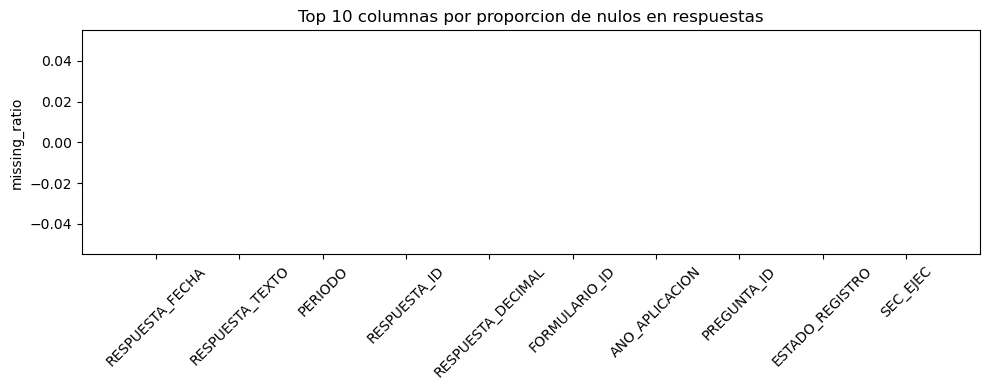

In [4]:
missing_by_column = respuestas_df.isna().mean().sort_values(ascending=False).reset_index()
missing_by_column.columns = ['column', 'missing_ratio']
display(missing_by_column)

fig, ax = plt.subplots(figsize=(10, 4))
top_missing = missing_by_column.head(10)
ax.bar(top_missing['column'], top_missing['missing_ratio'], color='tab:blue')
ax.set_title('Top 10 columnas por proporcion de nulos en respuestas')
ax.set_ylabel('missing_ratio')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### 3.2 Duplicados

En SISMEPRE la unicidad es especialmente importante porque `RESPUESTA_ID` deberia ayudar a identificar registros. Se revisan duplicados exactos y duplicados sobre ese identificador.


In [5]:
exact_duplicate_ratio = respuestas_df.duplicated().mean()
response_id_duplicate_ratio = respuestas_df.duplicated(subset=['RESPUESTA_ID']).mean()

duplicate_summary = pd.DataFrame([
    {'revision': 'Duplicados exactos', 'ratio': round(exact_duplicate_ratio, 4), 'records': int(respuestas_df.duplicated().sum())},
    {'revision': 'Duplicados por RESPUESTA_ID', 'ratio': round(response_id_duplicate_ratio, 4), 'records': int(respuestas_df.duplicated(subset=['RESPUESTA_ID']).sum())},
])
display(duplicate_summary)


,revision,ratio,records
0,Duplicados exactos,0.0000,0
1,Duplicados por RESPUESTA_ID,0.9989,174026


### 3.3 Cardinalidad y distribucion de categorias

Esta seccion resume la cobertura por ano, periodo, pregunta y entidad ejecutora. Asi se entiende rapidamente donde se concentra el volumen de respuestas.


In [6]:
cardinality_df = pd.DataFrame({
    'column': respuestas_df.columns,
    'unique_values': [respuestas_df[column].nunique(dropna=True) for column in respuestas_df.columns]
}).sort_values('unique_values', ascending=False)

year_counts = respuestas_df['ANO_APLICACION'].value_counts(dropna=False).sort_index().reset_index()
year_counts.columns = ['ANO_APLICACION', 'records']

period_counts = respuestas_df['PERIODO'].value_counts(dropna=False).sort_index().reset_index()
period_counts.columns = ['PERIODO', 'records']

top_questions = respuestas_df['PREGUNTA_ID'].value_counts(dropna=False).head(10).reset_index()
top_questions.columns = ['PREGUNTA_ID', 'records']

top_entities = respuestas_df['SEC_EJEC'].value_counts(dropna=False).head(10).reset_index()
top_entities.columns = ['SEC_EJEC', 'records']

display(cardinality_df)
display(year_counts)
display(period_counts)
display(top_questions)
display(top_entities)


,column,unique_values
4,RESPUESTA_DECIMAL,5310
10,RESPUESTA_ENTERO,4683
1,RESPUESTA_TEXTO,4656
9,SEC_EJEC,885
0,RESPUESTA_FECHA,723
3,RESPUESTA_ID,184
7,PREGUNTA_ID,142
5,FORMULARIO_ID,6
6,ANO_APLICACION,4
2,PERIODO,2


,ANO_APLICACION,records
0,2022,30600
1,2023,48024
2,2024,74336
3,2025,21250


,PERIODO,records
0,1,30600
1,2,143610


,PREGUNTA_ID,records
0,1,1836
1,37,1836
2,39,1836
3,40,1836
4,41,1836
5,42,1836
6,43,1836
7,48,1836
8,49,1836
9,53,1836


,SEC_EJEC,records
0,300440,468
1,301147,393
2,301298,393
3,301838,393
4,301189,393
5,301454,393
6,301330,393
7,300171,393
8,301081,393
9,300740,393


### 3.4 Perfil temporal

Aqui se observa la distribucion de respuestas por ano y periodo. Esta vista ayuda a explicar si la informacion esta concentrada en ciertos cortes temporales.


,ANO_APLICACION,PERIODO,records
0,2022,1,30600
1,2023,2,48024
2,2024,2,74336
3,2025,2,21250


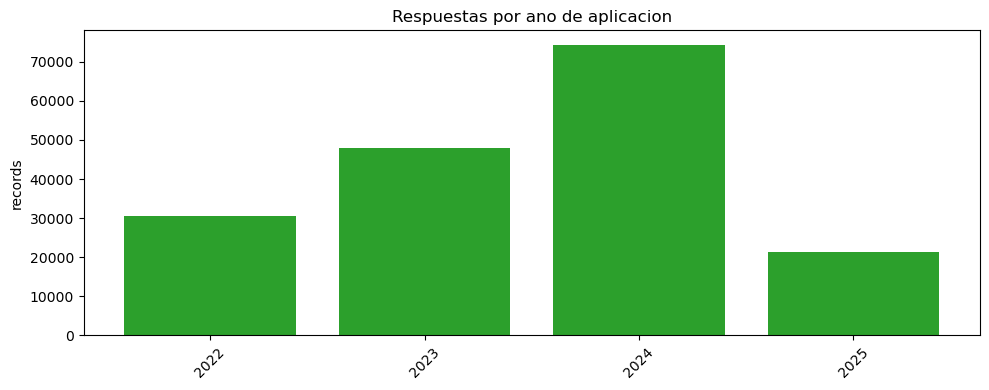

In [7]:
temporal_counts = respuestas_df.groupby(['ANO_APLICACION', 'PERIODO']).size().reset_index(name='records').sort_values(['ANO_APLICACION', 'PERIODO'])
display(temporal_counts)

fig, ax = plt.subplots(figsize=(10, 4))
year_labels = year_counts['ANO_APLICACION'].apply(lambda value: 'Sin año' if pd.isna(value) else str(int(value)))
ax.bar(year_labels, year_counts['records'], color='tab:green')
ax.set_title('Respuestas por ano de aplicacion')
ax.set_ylabel('records')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### 3.5 Perfil relacional

Como SISMEPRE es una fuente relacional, no basta con mirar la tabla principal. Tambien interesa saber si las claves de preguntas y formularios encuentran respaldo en sus catalogos.


In [8]:
question_keys = set(pd.to_numeric(preguntas_df['PREGUNTA_ID'], errors='coerce').dropna().astype(int).tolist()) if 'PREGUNTA_ID' in preguntas_df.columns else set()
form_keys = set(pd.to_numeric(formulario_df['FORMULARIO_ID'], errors='coerce').dropna().astype(int).tolist()) if 'FORMULARIO_ID' in formulario_df.columns else set()

question_match_ratio = respuestas_df['PREGUNTA_ID'].dropna().astype(int).isin(question_keys).mean() if question_keys else np.nan
form_match_ratio = respuestas_df['FORMULARIO_ID'].dropna().astype(int).isin(form_keys).mean() if form_keys else np.nan

relation_summary = pd.DataFrame([
    {'relacion': 'PREGUNTA_ID presente en catalogo de preguntas', 'score': round(question_match_ratio, 4)},
    {'relacion': 'FORMULARIO_ID presente en catalogo de formularios', 'score': round(form_match_ratio, 4)},
])
display(relation_summary)


,relacion,score
0,PREGUNTA_ID presente en catalogo de preguntas,1.0
1,FORMULARIO_ID presente en catalogo de formularios,1.0


## 4. Evaluacion de las 8 dimensiones de calidad

**A partir de esta seccion comienza formalmente la evaluacion de calidad de datos para SISMEPRE.** La evaluacion se centra en la tabla `rentas_respuestas.csv`, pero aprovecha los catalogos disponibles para validar relaciones y significado de los identificadores.


In [9]:
def classify_score(score: float) -> str:
    if pd.isna(score):
        return 'No evaluado'
    if score >= 0.95:
        return 'Alto'
    if score >= 0.80:
        return 'Medio'
    return 'Bajo'

core_columns = ['RESPUESTA_ID', 'PREGUNTA_ID', 'FORMULARIO_ID', 'ANO_APLICACION', 'PERIODO', 'SEC_EJEC']
missing_core_ratio = respuestas_df[core_columns].isna().mean().mean()

duplicate_ratio = respuestas_df.duplicated(subset=['RESPUESTA_ID']).mean()

valid_year_ratio = respuestas_df['ANO_APLICACION'].between(2012, 2026).mean()
valid_period_ratio = respuestas_df['PERIODO'].between(1, 12).mean()
valid_status_ratio = respuestas_df['ESTADO_REGISTRO'].fillna('').isin(['A', 'I', '']).mean() if 'ESTADO_REGISTRO' in respuestas_df.columns else np.nan
validez_ratio = np.nanmean([valid_year_ratio, valid_period_ratio, valid_status_ratio])

consistency_question_ratio = respuestas_df['PREGUNTA_ID'].dropna().astype(int).isin(question_keys).mean() if question_keys else np.nan
consistency_form_ratio = respuestas_df['FORMULARIO_ID'].dropna().astype(int).isin(form_keys).mean() if form_keys else np.nan
consistency_ratio = np.nanmean([consistency_question_ratio, consistency_form_ratio])

exact_entero_ratio = pd.to_numeric(respuestas_df['RESPUESTA_ENTERO'], errors='coerce').notna().mean() if 'RESPUESTA_ENTERO' in respuestas_df.columns else np.nan
exact_decimal_ratio = pd.to_numeric(respuestas_df['RESPUESTA_DECIMAL'], errors='coerce').notna().mean() if 'RESPUESTA_DECIMAL' in respuestas_df.columns else np.nan
exactitud_ratio = np.nanmean([exact_entero_ratio, exact_decimal_ratio])

integrity_ratio = respuestas_df[['SEC_EJEC', 'FORMULARIO_ID', 'PREGUNTA_ID']].notna().all(axis=1).mean()

observed_years = set(pd.to_numeric(respuestas_df['ANO_APLICACION'], errors='coerce').dropna().astype(int).unique())
catalog_years = set(pd.to_numeric(ano_aplicacion_df['ANO_APLICACION'], errors='coerce').dropna().astype(int).unique()) if not ano_aplicacion_df.empty and 'ANO_APLICACION' in ano_aplicacion_df.columns else set()
actualidad_ratio = len(observed_years & catalog_years) / len(observed_years) if observed_years else np.nan

trazabilidad_ratio = respuestas_df['source_file'].notna().mean()

quality_summary = pd.DataFrame([
    {'dimension': 'Completitud', 'metric': '1 - promedio de nulos en columnas clave', 'score': round(1 - missing_core_ratio, 4)},
    {'dimension': 'Unicidad', 'metric': '1 - proporcion de duplicados de RESPUESTA_ID', 'score': round(1 - duplicate_ratio, 4)},
    {'dimension': 'Validez', 'metric': 'reglas de ano, periodo y estado', 'score': round(validez_ratio, 4)},
    {'dimension': 'Consistencia', 'metric': 'existencia de PREGUNTA_ID y FORMULARIO_ID en sus catalogos', 'score': round(consistency_ratio, 4)},
    {'dimension': 'Exactitud', 'metric': 'capacidad de parsear respuestas numericas', 'score': round(exactitud_ratio, 4)},
    {'dimension': 'Integridad', 'metric': 'presencia conjunta de SEC_EJEC, FORMULARIO_ID y PREGUNTA_ID', 'score': round(integrity_ratio, 4)},
    {'dimension': 'Actualidad', 'metric': 'anos observados respaldados por el catalogo de aplicacion', 'score': round(actualidad_ratio, 4)},
    {'dimension': 'Trazabilidad', 'metric': 'presencia de source_file', 'score': round(trazabilidad_ratio, 4)},
])
quality_summary['nivel'] = quality_summary['score'].apply(classify_score)
quality_summary


,dimension,metric,score,nivel
0,Completitud,1 - promedio de nulos en columnas clave,1.0000,Alto
1,Unicidad,1 - proporcion de duplicados de RESPUESTA_ID,0.0011,Bajo
2,Validez,"reglas de ano, periodo y estado",1.0000,Alto
3,Consistencia,existencia de PREGUNTA_ID y FORMULARIO_ID en s...,1.0000,Alto
4,Exactitud,capacidad de parsear respuestas numericas,1.0000,Alto
5,Integridad,"presencia conjunta de SEC_EJEC, FORMULARIO_ID ...",1.0000,Alto
6,Actualidad,anos observados respaldados por el catalogo de...,1.0000,Alto
7,Trazabilidad,presencia de source_file,1.0000,Alto


### 4.1 Completitud

**Que significa:** revisar si los identificadores y campos base necesarios para analizar respuestas estan presentes.

**Como se midio:** se calculo el promedio de nulos en `RESPUESTA_ID`, `PREGUNTA_ID`, `FORMULARIO_ID`, `ANO_APLICACION`, `PERIODO` y `SEC_EJEC`.


In [10]:
completitud_detail = pd.DataFrame({
    'column': core_columns,
    'missing_ratio': respuestas_df[core_columns].isna().mean().round(4).values,
    'completeness_score': (1 - respuestas_df[core_columns].isna().mean()).round(4).values,
})
display(quality_summary[quality_summary['dimension'] == 'Completitud'])
display(completitud_detail)


,dimension,metric,score,nivel
0,Completitud,1 - promedio de nulos en columnas clave,1.0,Alto


,column,missing_ratio,completeness_score
0,RESPUESTA_ID,0.0,1.0
1,PREGUNTA_ID,0.0,1.0
2,FORMULARIO_ID,0.0,1.0
3,ANO_APLICACION,0.0,1.0
4,PERIODO,0.0,1.0
5,SEC_EJEC,0.0,1.0


### 4.2 Unicidad

**Que significa:** verificar si el identificador de respuesta se comporta realmente como un identificador unico.

**Como se midio:** se midio la proporcion de duplicados sobre `RESPUESTA_ID`.


In [11]:
unicidad_detail = pd.DataFrame([
    {'revision': 'Duplicados exactos', 'ratio': round(exact_duplicate_ratio, 4), 'records': int(respuestas_df.duplicated().sum())},
    {'revision': 'Duplicados por RESPUESTA_ID', 'ratio': round(duplicate_ratio, 4), 'records': int(respuestas_df.duplicated(subset=['RESPUESTA_ID']).sum())},
])
display(quality_summary[quality_summary['dimension'] == 'Unicidad'])
display(unicidad_detail)


,dimension,metric,score,nivel
1,Unicidad,1 - proporcion de duplicados de RESPUESTA_ID,0.0011,Bajo


,revision,ratio,records
0,Duplicados exactos,0.0000,0
1,Duplicados por RESPUESTA_ID,0.9989,174026


### 4.3 Validez

**Que significa:** comprobar si los valores estan dentro de rangos o codigos plausibles para la fuente.

**Como se midio:** se validaron anos, periodos y estado de registro.


In [12]:
validez_detail = pd.DataFrame([
    {'regla': 'ANO_APLICACION entre 2012 y 2026', 'score': round(valid_year_ratio, 4)},
    {'regla': 'PERIODO entre 1 y 12', 'score': round(valid_period_ratio, 4)},
    {'regla': 'ESTADO_REGISTRO en A o I', 'score': round(valid_status_ratio, 4)},
])
display(quality_summary[quality_summary['dimension'] == 'Validez'])
display(validez_detail)


,dimension,metric,score,nivel
2,Validez,"reglas de ano, periodo y estado",1.0,Alto


,regla,score
0,ANO_APLICACION entre 2012 y 2026,1.0
1,PERIODO entre 1 y 12,1.0
2,ESTADO_REGISTRO en A o I,1.0


### 4.4 Consistencia

**Que significa:** revisar si los identificadores usados en respuestas coinciden con los catalogos de apoyo.

**Como se midio:** se verifico si `PREGUNTA_ID` existe en la tabla de preguntas y si `FORMULARIO_ID` existe en la tabla de formularios.


In [13]:
consistencia_detail = pd.DataFrame([
    {'regla': 'PREGUNTA_ID existe en preguntas', 'score': round(consistency_question_ratio, 4)},
    {'regla': 'FORMULARIO_ID existe en formularios', 'score': round(consistency_form_ratio, 4)},
])
display(quality_summary[quality_summary['dimension'] == 'Consistencia'])
display(consistencia_detail)


,dimension,metric,score,nivel
3,Consistencia,existencia de PREGUNTA_ID y FORMULARIO_ID en s...,1.0,Alto


,regla,score
0,PREGUNTA_ID existe en preguntas,1.0
1,FORMULARIO_ID existe en formularios,1.0


### 4.5 Exactitud

**Que significa:** en esta fuente, una buena aproximacion a exactitud es revisar si las columnas numericas pueden interpretarse realmente como numeros.

**Como se midio:** se calculo la proporcion de valores parseables en `RESPUESTA_ENTERO` y `RESPUESTA_DECIMAL`.


In [14]:
exactitud_detail = pd.DataFrame([
    {'regla': 'RESPUESTA_ENTERO parseable', 'score': round(exact_entero_ratio, 4)},
    {'regla': 'RESPUESTA_DECIMAL parseable', 'score': round(exact_decimal_ratio, 4)},
])
display(quality_summary[quality_summary['dimension'] == 'Exactitud'])
display(exactitud_detail)


,dimension,metric,score,nivel
4,Exactitud,capacidad de parsear respuestas numericas,1.0,Alto


,regla,score
0,RESPUESTA_ENTERO parseable,1.0
1,RESPUESTA_DECIMAL parseable,1.0


### 4.6 Integridad

**Que significa:** evaluar si cada respuesta trae juntos los identificadores minimos para enlazarse con el resto del sistema.

**Como se midio:** se verifico la presencia conjunta de `SEC_EJEC`, `FORMULARIO_ID` y `PREGUNTA_ID`.


In [15]:
integridad_detail = pd.DataFrame([
    {'regla': 'SEC_EJEC, FORMULARIO_ID y PREGUNTA_ID presentes', 'score': round(integrity_ratio, 4), 'complete_rows': int(respuestas_df[['SEC_EJEC', 'FORMULARIO_ID', 'PREGUNTA_ID']].notna().all(axis=1).sum())},
])
display(quality_summary[quality_summary['dimension'] == 'Integridad'])
display(integridad_detail)


,dimension,metric,score,nivel
5,Integridad,"presencia conjunta de SEC_EJEC, FORMULARIO_ID ...",1.0,Alto


,regla,score,complete_rows
0,"SEC_EJEC, FORMULARIO_ID y PREGUNTA_ID presentes",1.0,174210


### 4.7 Actualidad

**Que significa:** revisar si los anos observados en respuestas estan respaldados por el catalogo temporal disponible en la fuente.

**Como se midio:** se compararon los anos presentes en `rentas_respuestas.csv` contra el catalogo `rentas_ano_aplicacion.csv`.


In [16]:
actualidad_detail = pd.DataFrame({
    'observed_years': sorted(observed_years),
    'years_supported_by_catalog': [len(observed_years & catalog_years)] + [np.nan] * max(len(observed_years) - 1, 0)
})
display(quality_summary[quality_summary['dimension'] == 'Actualidad'])
display(actualidad_detail)


,dimension,metric,score,nivel
6,Actualidad,anos observados respaldados por el catalogo de...,1.0,Alto


,observed_years,years_supported_by_catalog
0,2022,4.0
1,2023,NaN
2,2024,NaN
3,2025,NaN


### 4.8 Trazabilidad

**Que significa:** asegurar que el origen del registro siga visible despues de la carga.

**Como se midio:** se reviso la presencia de `source_file` en la tabla principal.


In [17]:
trazabilidad_detail = respuestas_df['source_file'].value_counts(dropna=False).reset_index()
trazabilidad_detail.columns = ['source_file', 'records']
display(quality_summary[quality_summary['dimension'] == 'Trazabilidad'])
display(trazabilidad_detail)


,dimension,metric,score,nivel
7,Trazabilidad,presencia de source_file,1.0,Alto


,source_file,records
0,rentas_respuestas.csv,174210


## 5. Resumen consolidado

Esta tabla resume las ocho dimensiones, la logica usada para medirlas y una interpretacion simple del resultado. Es la tabla mas util para una defensa oral rapida.


In [18]:
display(quality_summary)


,dimension,metric,score,nivel
0,Completitud,1 - promedio de nulos en columnas clave,1.0000,Alto
1,Unicidad,1 - proporcion de duplicados de RESPUESTA_ID,0.0011,Bajo
2,Validez,"reglas de ano, periodo y estado",1.0000,Alto
3,Consistencia,existencia de PREGUNTA_ID y FORMULARIO_ID en s...,1.0000,Alto
4,Exactitud,capacidad de parsear respuestas numericas,1.0000,Alto
5,Integridad,"presencia conjunta de SEC_EJEC, FORMULARIO_ID ...",1.0000,Alto
6,Actualidad,anos observados respaldados por el catalogo de...,1.0000,Alto
7,Trazabilidad,presencia de source_file,1.0000,Alto


## 6. Conclusiones

Las conclusiones recogen lo principal del profiling y tambien dejan documentadas las incidencias que el pipeline encontro durante la carga.


In [19]:
missing_files = availability_df.loc[~availability_df['available_in_bronze'], 'filename'].tolist()
worst_dimension = quality_summary.sort_values('score').iloc[0]
conclusion_lines = [
    f'- La tabla principal de respuestas contiene {len(respuestas_df):,} filas.'.replace(',', '.'),
    f'- Hay {int(availability_df["available_in_bronze"].sum())} archivos disponibles de {len(expected_files)} esperados.',
    f'- Los archivos faltantes son: {missing_files if missing_files else "ninguno"}.',
    f'- La dimension que requiere mas explicacion es {worst_dimension["dimension"]} con score {worst_dimension["score"]:.4f}.',
    '- SISMEPRE es util porque sus respuestas pueden relacionarse con preguntas y formularios, no es solo un CSV aislado.'
]
display(Markdown('\n'.join(conclusion_lines)))


- La tabla principal de respuestas contiene 174.210 filas.
- Hay 13 archivos disponibles de 14 esperados.
- Los archivos faltantes son: ['rentas_entidad_estado_diccionario.csv'].
- La dimension que requiere mas explicacion es Unicidad con score 0.0011.
- SISMEPRE es util porque sus respuestas pueden relacionarse con preguntas y formularios, no es solo un CSV aislado.

## 7. Recomendaciones

Estas recomendaciones muestran como usar el profiling para mejorar el trabajo posterior con la fuente.


In [20]:
recommendation_lines = [
    '- Revisar la logica de unicidad de `RESPUESTA_ID` antes de usarlo como llave unica en analisis o modelos posteriores.',
    '- Mantener la validacion de integridad referencial entre respuestas, preguntas y formularios como control automatico del pipeline.',
    '- Documentar el archivo faltante del diccionario para explicar la limitacion del aterrizaje API.',
    '- Si se construye una capa Silver, separar respuestas numericas y textuales con reglas explicitas de tipado.'
]
display(Markdown('\n'.join(recommendation_lines)))


- Revisar la logica de unicidad de `RESPUESTA_ID` antes de usarlo como llave unica en analisis o modelos posteriores.
- Mantener la validacion de integridad referencial entre respuestas, preguntas y formularios como control automatico del pipeline.
- Documentar el archivo faltante del diccionario para explicar la limitacion del aterrizaje API.
- Si se construye una capa Silver, separar respuestas numericas y textuales con reglas explicitas de tipado.